# Ecommerce Customer and Sales analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/data.csv", encoding="latin1")

## Understanding the dataset

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Check null vaues 

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Check duplicated values

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [10]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [11]:
df[df["UnitPrice"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [12]:
df[df["InvoiceNo"].str.startswith("C")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [13]:
df["InvoiceDate"].head(10)

0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
5    12/1/2010 8:26
6    12/1/2010 8:26
7    12/1/2010 8:28
8    12/1/2010 8:28
9    12/1/2010 8:34
Name: InvoiceDate, dtype: str

In [14]:
df["InvoiceDate"].tail(10)

541899    12/9/2011 12:50
541900    12/9/2011 12:50
541901    12/9/2011 12:50
541902    12/9/2011 12:50
541903    12/9/2011 12:50
541904    12/9/2011 12:50
541905    12/9/2011 12:50
541906    12/9/2011 12:50
541907    12/9/2011 12:50
541908    12/9/2011 12:50
Name: InvoiceDate, dtype: str

In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [16]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

## Remove Duplicate Transactions

The dataset contained 5,268 exact duplicate rows. These duplicates were removed to prevent the same transaction from being counted multiple times in sales and customer analysis.

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(536641, 8)

## Handle Missing Product Descriptions

The `Description` column contains 1,454 missing values. Since these transactions may still be useful for sales analysis and the `StockCode` is available as a product identifier, missing descriptions are replaced with `Unknown Product`.

In [19]:
df["Description"] = df["Description"].fillna("Unknown Product")

In [20]:
df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

##  Calculate Revenue

In [21]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [22]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'IsCancelled', 'Revenue'],
      dtype='str')

In [24]:
df = df[~df["InvoiceNo"].str.startswith("A")]

## Sales dataset

In [25]:
sales_df = df[df["IsCancelled"] == False].copy()


## Cancellation dataset

In [26]:
returns_df = df[df["IsCancelled"] == True].copy()

In [27]:
df.to_csv("../data/data_cleaned.csv", index=False)

### Total Revenue

In [28]:
total_revenue = sales_df["Revenue"].sum()
total_revenue

np.float64(10631048.743999999)

### Total Quantity

In [29]:
total_quantity = sales_df["Quantity"].sum()
total_quantity

np.int64(5438059)

### Total Orders

In [30]:
total_orders = sales_df["InvoiceNo"].nunique()
total_orders

22061

### Total Customers

In [31]:
total_customers = sales_df["CustomerID"].nunique()
total_customers

4339

### Average Order Value

In [32]:
average_order_value = total_revenue / total_orders
average_order_value

np.float64(481.89332958614744)


## Monthly sales

In [33]:
monthly_sales = (
    sales_df
    .groupby(sales_df["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)
monthly_sales

,InvoiceDate,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,746779.320
9,2011-09,1056435.192


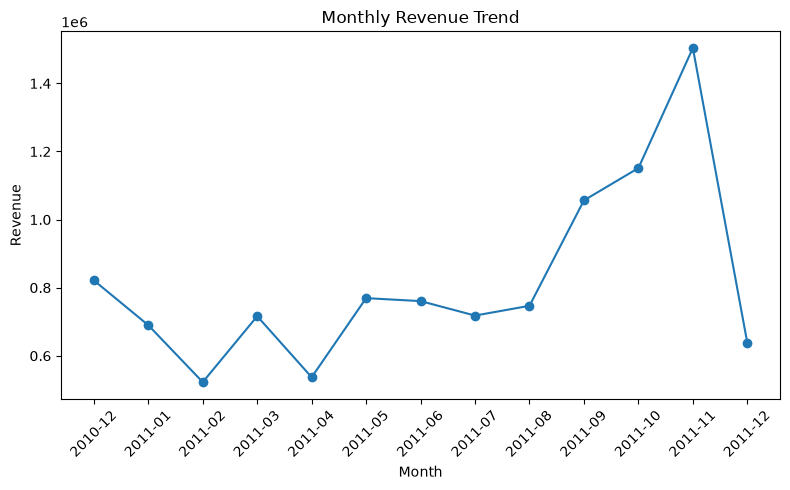

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_sales["InvoiceDate"].astype(str),
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Product Revenue

In [35]:
product_sales_df = sales_df[
    ~sales_df["Description"].isin([
        "DOTCOM POSTAGE",
        "POSTAGE",
        "Manual"
    ])
].copy()

In [36]:
product_revenue = (
    product_sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
product_revenue

Description
REGENCY CAKESTAND 3 TIER               174156.54
PAPER CRAFT , LITTLE BIRDIE            168469.60
WHITE HANGING HEART T-LIGHT HOLDER     106236.72
PARTY BUNTING                           99445.23
JUMBO BAG RED RETROSPOT                 94159.81
                                         ...    
adjustment                                  0.00
alan hodge cant mamage this section         0.00
allocate stock for dotcom orders ta         0.00
amazon                                      0.00
wrongly sold sets                           0.00
Name: Revenue, Length: 4204, dtype: float64

In [37]:
top_10_products = product_revenue.head(10)
top_10_products

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

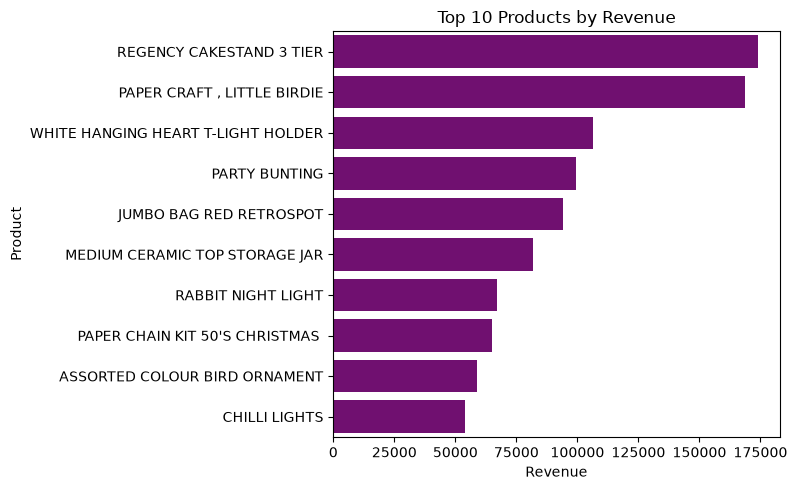

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index,
    color="purple"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

## Customer Revenue

In [39]:
customer_revenue = (
    sales_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [40]:
top_10_customers=customer_revenue.head(10)
top_10_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

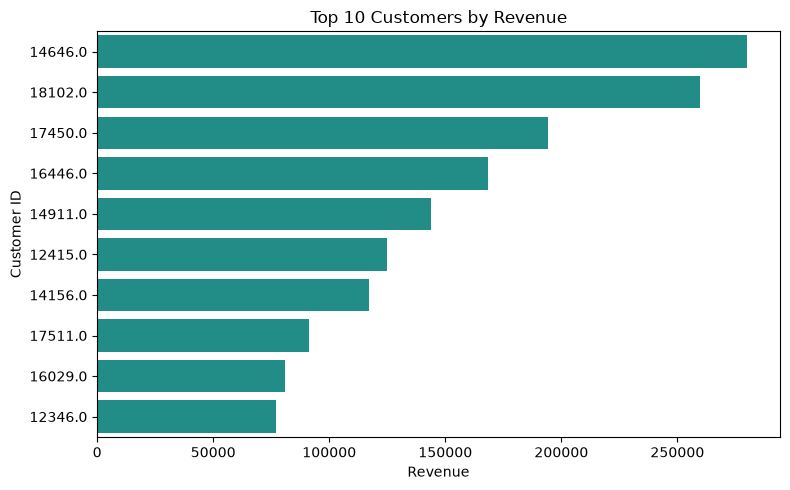

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_customers.values,
    y=top_10_customers.index.astype(str),
    color="#109e95"
    
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

## Customer order frequency

In [42]:
customer_orders = (
    sales_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

In [43]:
top_10_frequent_customers = customer_orders.head(10)
top_10_frequent_customers

CustomerID
12748.0    210
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     74
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

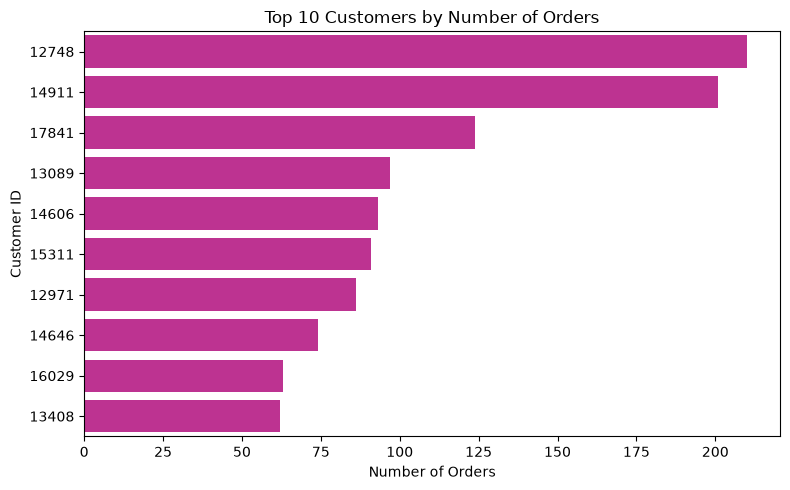

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_frequent_customers.values,
    y=top_10_frequent_customers.index.astype(int).astype(str),
    color="#d41c99"
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

## Revenue by country

In [45]:
country_revenue=(
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [46]:
top_10_countries=country_revenue.head(10)
top_10_countries

Country
United Kingdom    8990682.034
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

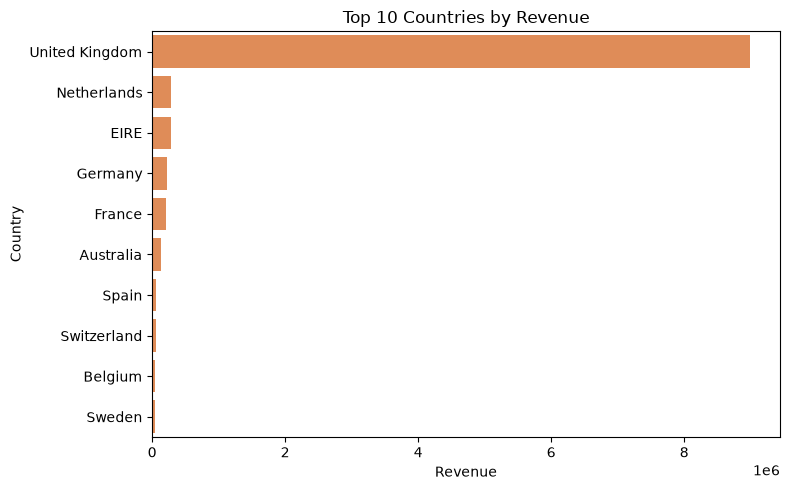

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index,
    color="#f58742"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## Quantity sold by product

In [48]:
product_quantity = (
    product_sales_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

In [49]:
top_10_quantity_products=product_quantity.head(10)
top_10_quantity_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

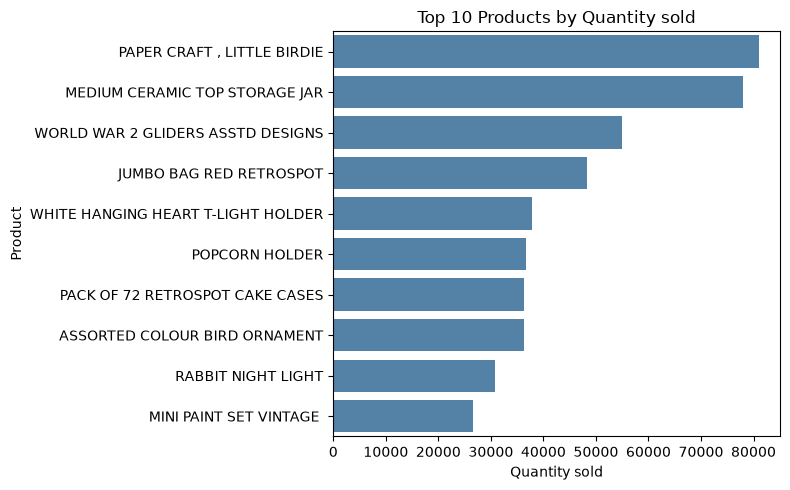

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_quantity_products.values,
    y=top_10_quantity_products.index,
    color="steelblue"
)

plt.title("Top 10 Products by Quantity sold")
plt.xlabel("Quantity sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Calculate average order value

In [51]:
total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()

aov = total_revenue / total_orders
aov

np.float64(481.89332958614744)

## No of orders per customers

In [52]:
repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

repeat_customers, one_time_customers

(np.int64(2845), np.int64(1494))

In [53]:
total_customers = repeat_customers + one_time_customers

repeat_percentage = (repeat_customers / total_customers) * 100
one_time_percentage = (one_time_customers / total_customers) * 100

repeat_percentage, one_time_percentage

(np.float64(65.56810324959667), np.float64(34.43189675040332))

In [54]:
customer_type = pd.DataFrame({
    "Customer Type": ["Repeat Customers", "One-Time Customers"],
    "Percentage": [repeat_percentage, one_time_percentage]
})

customer_type

,Customer Type,Percentage
0,Repeat Customers,65.568103
1,One-Time Customers,34.431897


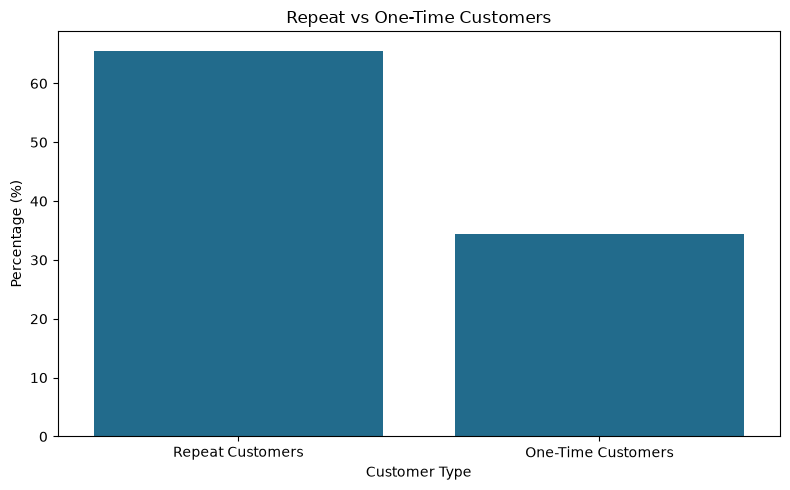

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type,
    x="Customer Type",
    y="Percentage",
    color="#10719e"
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

## Sales by days of week

In [56]:
sales_df["DaysOfWeek"]=sales_df["InvoiceDate"].dt.day_name()

In [57]:
day_revenue = (
    sales_df
    .groupby("DaysOfWeek")["Revenue"]
    .sum()
)

In [58]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = day_revenue.reindex(day_order)
day_revenue=day_revenue.fillna(0)
day_revenue

DaysOfWeek
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1826408.431
Saturday           0.000
Sunday        806790.781
Name: Revenue, dtype: float64

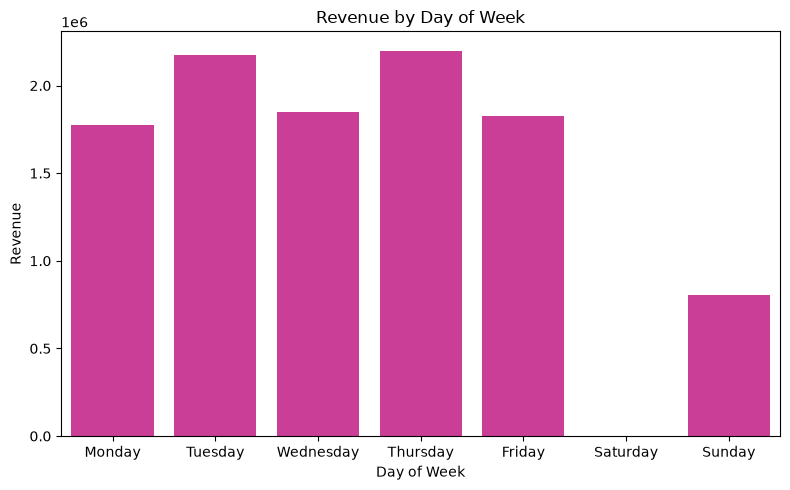

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=day_revenue.index,
    y=day_revenue.values,
    color="#e3279e"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Sales by hour

In [60]:
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

In [61]:
hour_revenue = (
    sales_df
    .groupby("Hour")["Revenue"]
    .sum()
    .sort_index()
)
hour_revenue

Hour
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1166845.461
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: Revenue, dtype: float64

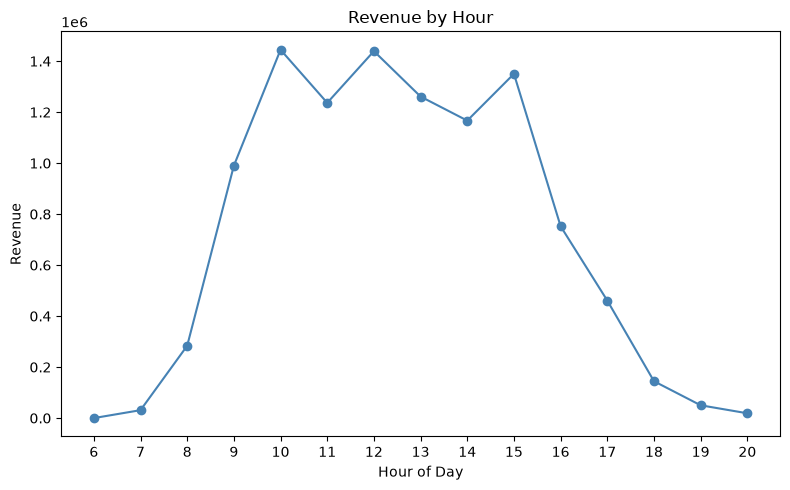

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    hour_revenue.index,
    hour_revenue.values,
    marker="o",
    color="steelblue"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.xticks(range(6, 21))
plt.tight_layout()
plt.show()

## Returns and Cancellation Analysis

In [65]:
cancellation_counts = df["IsCancelled"].value_counts()
cancellation_counts

IsCancelled
False    527387
True       9251
Name: count, dtype: int64

In [66]:
cancellation_percentage = (
    df["IsCancelled"].mean() * 100
)

cancellation_percentage

np.float64(1.7238809029550648)

In [67]:
cancelled_quantity = df.loc[
    df["IsCancelled"], "Quantity"
].abs().sum()

cancelled_quantity

np.int64(275560)

In [68]:
cancelled_revenue = df.loc[
    df["IsCancelled"], "Revenue"
].abs().sum()

cancelled_revenue

np.float64(893979.73)

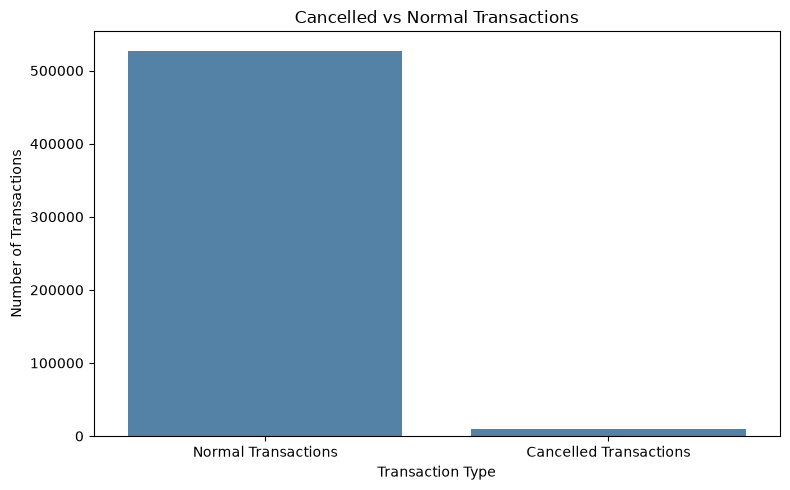

In [72]:
cancellation_labels = ["Normal Transactions", "Cancelled Transactions"]
cancellation_values = [
    cancellation_counts[False],
    cancellation_counts[True]
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cancellation_labels,
    y=cancellation_values,
    color="steelblue"
)

plt.title("Cancelled vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Customer spending distribution

In [73]:
customer_revenue.describe()

count      4339.000000
mean       2048.215924
std        8984.248352
min           0.000000
25%         306.455000
50%         668.560000
75%        1660.315000
max      280206.020000
Name: Revenue, dtype: float64

In [75]:
upper_limit = customer_revenue.quantile(0.99)

customer_revenue_filtered = customer_revenue[
    customer_revenue <= upper_limit
]

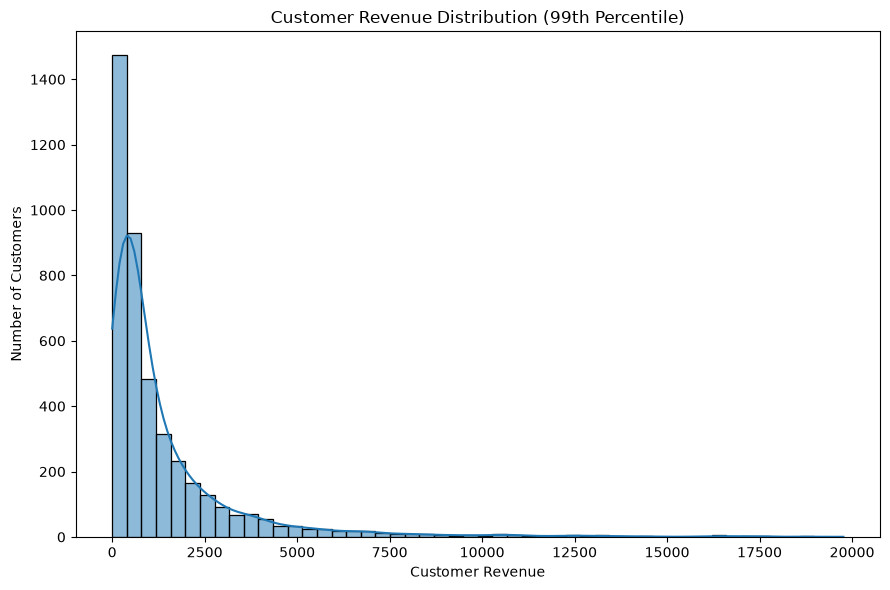

In [76]:
plt.figure(figsize=(9, 6))

sns.histplot(
    customer_revenue_filtered,
    bins=50,
    kde=True
)

plt.title("Customer Revenue Distribution (99th Percentile)")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## KPI Summary

In [77]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Cancellation Rate",
        "Cancelled Quantity",
        "Cancelled Transaction Value"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_orders,
        total_customers,
        average_order_value,
        cancellation_percentage,
        cancelled_quantity,
        cancelled_revenue
    ]
})

final_kpis

,KPI,Value
0,Total Revenue,1.063105e+07
1,Total Quantity Sold,5.438059e+06
2,Total Orders,2.206100e+04
3,Total Customers,4.339000e+03
4,Average Order Value,4.818933e+02
5,Cancellation Rate,1.723881e+00
6,Cancelled Quantity,2.755600e+05
7,Cancelled Transaction Value,8.939797e+05


## Business Insights

- The business generated approximately £10.66 million in revenue from the analyzed sales transactions.

- The United Kingdom generated the highest revenue, followed by the Netherlands, EIRE, Germany, and France.

- REGENCY CAKESTAND 3 TIER was the highest-revenue product, followed by PAPER CRAFT, LITTLE BIRDIE and WHITE HANGING HEART T-LIGHT HOLDER.

- A small group of customers generated a disproportionately large amount of revenue, indicating the presence of high-value customers.

- Approximately 65.57% of identified customers were repeat customers, while 34.43% were one-time customers.

- Thursday generated the highest revenue among the recorded days, while Sunday generated the lowest revenue among days with sales. No Saturday transactions were recorded in the dataset.

- Revenue was concentrated during daytime hours, with the strongest individual hour being around 10 AM.

- Approximately 1.72% of transaction records were cancelled. These cancellations involved approximately 275,560 units and a transaction value of approximately £893,980.

- Customer revenue was strongly right-skewed, meaning most customers generated relatively lower revenue while a small number of customers generated exceptionally high revenue.

## Conclusion

This E-Commerce Customer & Sales Analysis provided a detailed view of the business's sales performance, customer behavior, product performance, and transaction activity. The analysis showed that revenue was concentrated in a small number of countries, products, and high-value customers, while a large proportion of identified customers were repeat purchasers.

The analysis also identified clear patterns in sales over time, including strong daytime purchasing activity and differences in revenue across days of the week. Cancellation analysis showed that although cancelled transactions represented a relatively small percentage of total transactions, they involved a significant number of units and transaction value.

Overall, the analysis demonstrates how data can be used to identify top-performing products and customers, understand purchasing patterns, monitor cancellations, and support data-driven business decisions. 